#### Import libraries and load data

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk

# Set plotting style
sns.set_theme(style="whitegrid")

langs = ['eng', 'zho', 'nld']
datasets = {}

# Load data from the directory we just downloaded to
for lang in langs:
    path = f"../data/raw/{lang}_dataset"
    if os.path.exists(path):
        datasets[lang] = load_from_disk(path)
        print(f"Loaded {lang}: {datasets[lang]['train'].num_rows} documents.")
    else:
        print(f"Path not found: {path}")

Loaded eng: 137710 documents.
Loaded zho: 203891 documents.
Loaded nld: 304611 documents.


#### Extract features and compute statistics 

In [ ]:
# To speed up computation, we randomly sample 10,000 rows from each language for EDA
sample_size = 10000
data_stats = []

for lang, ds in datasets.items():
    # Get the training set and sample
    train_split = ds['train']
    actual_sample_size = min(sample_size, len(train_split))
    sampled_data = train_split.shuffle(seed=42).select(range(actual_sample_size))
    
    for item in sampled_data:
        text = item['text']
        # Simple calculation of character length and rough word count 
        # (characters for ZH, space-separated words for EN/NL)
        char_length = len(text)
        word_count = len(text.split()) if lang != 'zh' else char_length
        
        data_stats.append({
            'Language': lang.upper(),
            'Character Length': char_length,
            'Rough Word Count': word_count
        })

df_stats = pd.DataFrame(data_stats)
display(df_stats.groupby('Language').describe())

Character Length                                               \
                    count       mean           std   min    25%    50%   
Language                                                                 
ENG               10000.0  3819.7640  21583.594051  11.0  178.0  389.0   
NLD               10000.0  2139.0952  22465.853461  17.0  143.0  285.0   
ZHO               10000.0   944.5255   2002.021669   3.0   57.0  302.0   

                             Rough Word Count                              \
              75%        max            count      mean          std  min   
Language                                                                    
ENG       1026.25   744455.0          10000.0  700.2680  3970.596766  3.0   
NLD        521.00  2049911.0          10000.0  409.7520  3637.444628  2.0   
ZHO        724.00    65618.0          10000.0   77.9278   259.318752  1.0   

                                       
           25%   50%    75%       max  
Language                               
ENG       30.0  66.0  173.0  133589.0  
NLD       25.0  50.0   90.0  317894.0  
ZHO        1.0  10.0   23.0    9676.0

#### Visualize length distribution

/var/folders/zm/s3nl0q4959v39_q9fkwm3xvw0000gn/T/ipykernel_93258/4180826010.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats, x='Language', y='Character Length', palette="Set2")


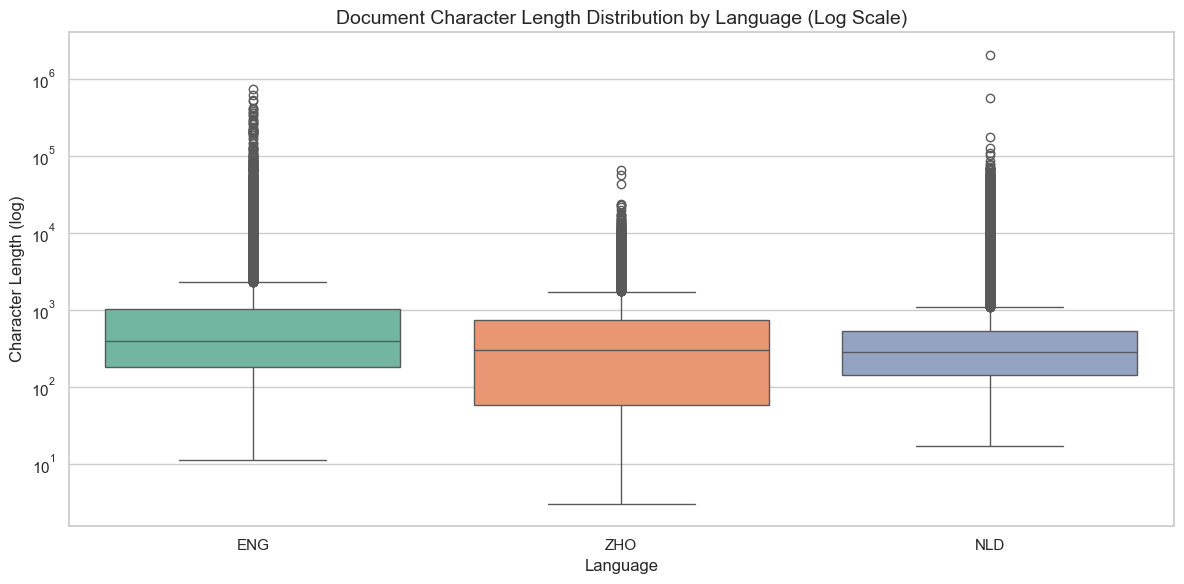

In [3]:
plt.figure(figsize=(12, 6))

# Use a logarithmic scale for character length distribution to handle outliers
sns.boxplot(data=df_stats, x='Language', y='Character Length', palette="Set2")
plt.title("Document Character Length Distribution by Language (Log Scale)", fontsize=14)
plt.yscale('log')
plt.ylabel("Character Length (log)", fontsize=12)
plt.xlabel("Language", fontsize=12)

plt.tight_layout()
plt.show()

#### Inspect the mixed data

In [116]:
import pandas as pd
from datasets import load_from_disk

# Load the Stage 1 data we just mixed
# (假設我們跑的是 10M 測試預算)
stage1_path = "../data/processed_10M/Stage_1_Foundation"
mixed_ds = load_from_disk(stage1_path)

print(f"Total Rows: {len(mixed_ds):,}")

# Convert the first 10 rows to a Pandas DataFrame for easy viewing
df_preview = pd.DataFrame(mixed_ds['train'].select(range(10)))

# Display the preview
#print("\n--- Data Preview ---")
#display(df_preview)

# Verify if the mixing ratio meets expectations
print("\n--- Row Count by Language ---")
# 注意：這裡是 Row 數量比例，不是 Token 比例。
# 因為英文單字佔的 Row 通常比中文長，所以 Row 比例不會剛好等於 50:25:25，這是正常的！
df_all = pd.DataFrame(mixed_ds['train'])
display(df_all['language'].value_counts(normalize=True).round(4) * 100)

Total Rows: 2

--- Row Count by Language ---


language
nld    36.97
eng    36.80
zho    26.23
Name: proportion, dtype: float64

#### Qualitative Tokenizer Check

In [117]:
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_file("../tokenizers/tokenizer_10M_16000v.json")


# Define some "difficult/high-frequency" test sentences for the three languages
test_sentences = {
    "ENG": [
        "Language modeling is a fascinating subfield of artificial intelligence.",
        "The quick brown fox jumps over the lazy dog.",
        "Unbelievable architectural optimization techniques." # 測試字首字尾拆解
    ],
    "ZHO": [
        "因为我们有强大的计算资源，所以模型训练速度非常快。", # 測試常見連接詞
        "自然语言处理是一个充满挑战的领域。", # 測試專有名詞
        "这是一个不合理的超参数设定。" # 測試否定詞與專有名詞
    ],
    "NLD": [
        "Natuurlijke taalverwerking is een fascinerend deelgebied van kunstmatige intelligentie.",
        "De snelle bruine vos springt over de luie hond.",
        "Onwaarschijnlijke architectonische optimalisatietechnieken."
    ]
}

print("=== Tokenizer Qualitative Check ===\n")

for lang, sentences in test_sentences.items():
    print(f"--- {lang} ---")
    for text in sentences:
        encoded = tokenizer.encode(text)
        

        # Key modification: Do not print encoded.tokens. Decode each ID back to text individually.
        readable_tokens = []
        for token_id in encoded.ids:
            # decode 會把 ID 轉回原本的 UTF-8 詞彙
            decoded_word = tokenizer.decode([token_id])
            
            # 清理一下空白，讓排版更好看
            clean_word = decoded_word.strip()
            if not clean_word:
                clean_word = "_" # 代表空白 token
            readable_tokens.append(clean_word)
        
        print(f"Original : {text}")
        print(f"Tokens   : {' | '.join(readable_tokens)}")
        print(f"Count    : {len(encoded.ids)} tokens")
        print("-" * 40)
    print("\n")

=== Tokenizer Qualitative Check ===

--- ENG ---
Original : Language modeling is a fascinating subfield of artificial intelligence.
Tokens   : L | ang | uage | mod | eling | is | a | fasc | in | ating | sub | field | of | art | ific | ial | intelligence | .
Count    : 18 tokens
----------------------------------------
Original : The quick brown fox jumps over the lazy dog.
Tokens   : The | quick | brown | fox | jumps | over | the | lazy | dog | .
Count    : 10 tokens
----------------------------------------
Original : Unbelievable architectural optimization techniques.
Tokens   : Un | bel | iev | able | architect | ural | opt | im | ization | techn | iqu | es | .
Count    : 13 tokens
----------------------------------------


--- ZHO ---
Original : 因为我们有强大的计算资源，所以模型训练速度非常快。
Tokens   : 因为 | 我们 | 有 | 强 | 大的 | 计 | 算 | 资 | 源 | _ | 所以 | � | � | � | � | 训 | 练 | � | � | 度 | 非常 | 快 | _
Count    : 23 tokens
----------------------------------------
Original : 自然语言处理是一个充满挑战的领域。
Tokens   : 自 | 然 |

#### Evaluation Tokenizer

✅ Tokenizer load success! Vocab size: 16,000
loading test samples...


,Language,Total Base Units,Total Tokens,Fertility (Tokens/Unit),UNK Rate (%)
0,eng,7002680,11775567,1.681580,0.0
1,nld,4097520,6163739,1.504261,0.0
2,zho,9445255,8821917,0.934005,0.0


/var/folders/zm/s3nl0q4959v39_q9fkwm3xvw0000gn/T/ipykernel_26216/4224354044.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Language", y="Fertility (Tokens/Unit)", data=df_results, palette="viridis")


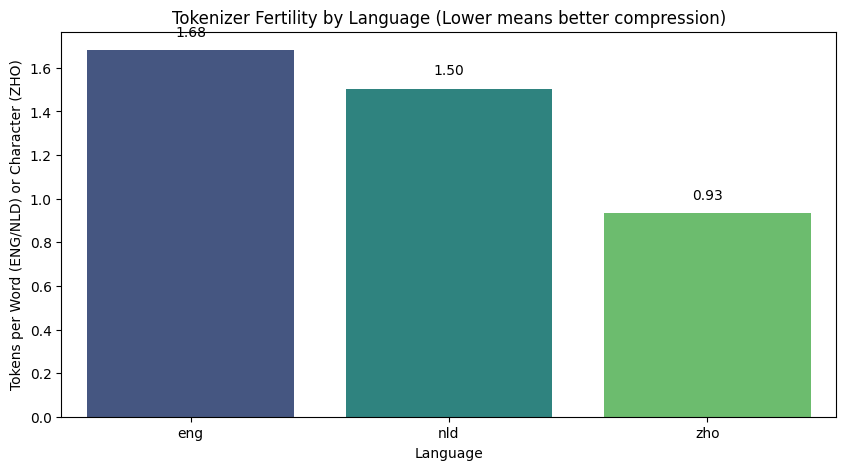


========== Byte Premium Alignment Check ==========
[ENG] relative ratio: 1.0000 | official Byte Premium: 1.0000 | difference: 0.0000
[NLD] relative ratio: 0.5234 | official Byte Premium: 1.0516 | difference: 0.5282
  -> ⚠️ warning: nld has a significant deviation from the official Byte Premium, consider adjusting training data ratio or BPE algorithm.
[ZHO] relative ratio: 0.7492 | official Byte Premium: 0.9894 | difference: 0.2402
  -> ⚠️ warning: zho has a significant deviation from the official Byte Premium, consider adjusting training data ratio or BPE algorithm.


In [118]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk
from transformers import PreTrainedTokenizerFast

# 1. load Tokenizer
tokenizer_path = "../tokenizers/tokenizer_10M_16000v.json"
try:
    tokenizer = PreTrainedTokenizerFast(
        tokenizer_file=tokenizer_path,
        unk_token="<unk>",
        bos_token="<s>",
        eos_token="</s>",
        pad_token="<pad>",
        mask_token="<mask>"
    )
    print(f"✅ Tokenizer load success! Vocab size: {tokenizer.vocab_size:,}")
except Exception as e:
    print(f"❌ Error loading tokenizer: {e}")

# 2. prepare test data (randomly sample 10,000 texts from each language's raw dataset)
langs = ['eng', 'nld', 'zho']
sample_size = 10000
texts = {}

print("loading test samples...")
for lang in langs:
    ds_path = f"../data/raw/{lang}_dataset"
    if os.path.exists(ds_path):
        ds = load_from_disk(ds_path)
        # randomly sample texts from the training split, ensuring evaluation is not biased by data order
        texts[lang] = ds['train'].shuffle(seed=42).select(range(sample_size))['text']
    else:
        print(f"找不到資料集: {ds_path}")

# 3. key evaluation function to compute fertility and UNK rate
def evaluate_tokenizer(tokenizer, texts, lang):
    total_words_or_chars = 0
    total_tokens = 0
    unk_count = 0
    
    for text in texts:
        # count words for ENG/NLD, characters for ZHO
        if lang == 'zho':
            total_words_or_chars += len(text)
        else:
            total_words_or_chars += len(text.split())
            
        # execute Tokenize
        encoded_ids = tokenizer.encode(text)
        total_tokens += len(encoded_ids)
        unk_count += encoded_ids.count(tokenizer.unk_token_id)
        
    # Fertility (each base unit is split into how many tokens, lower is better compression)
    fertility = total_tokens / total_words_or_chars if total_words_or_chars > 0 else 0
    # UNK Rate (unknown token ratio)
    unk_rate = (unk_count / total_tokens) * 100 if total_tokens > 0 else 0
    
    return {
        "Language": lang,
        "Total Base Units": total_words_or_chars,
        "Total Tokens": total_tokens,
        "Fertility (Tokens/Unit)": fertility,
        "UNK Rate (%)": unk_rate
    }

# 4. compute evaluation metrics for each language and compile results into a DataFrame
results = []
for lang in langs:
    if lang in texts:
        res = evaluate_tokenizer(tokenizer, texts[lang], lang)
        results.append(res)
        
df_results = pd.DataFrame(results)
display(df_results)

# 5. visualize fertility results
plt.figure(figsize=(10, 5))
sns.barplot(x="Language", y="Fertility (Tokens/Unit)", data=df_results, palette="viridis")
plt.title("Tokenizer Fertility by Language (Lower means better compression)")
plt.ylabel("Tokens per Word (ENG/NLD) or Character (ZHO)")
for index, value in enumerate(df_results["Fertility (Tokens/Unit)"]):
    plt.text(index, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
plt.show()

# 6. examine Byte Premium Alignment
official_premiums = {'eng': 1.0, 'nld': 1.0516, 'zho': 0.9894}

print("\n========== Byte Premium Alignment Check ==========")
try:
    eng_tokens = df_results[df_results['Language'] == 'eng']['Total Tokens'].values[0]
    
    for lang in langs:
        actual_tokens = df_results[df_results['Language'] == lang]['Total Tokens'].values[0]
        # 假設以英文的 Token 總數為基準 (1.0)，觀察其他語言的相對 Token 消耗量
        relative_ratio = actual_tokens / eng_tokens
        official_ratio = official_premiums[lang]
        diff = abs(relative_ratio - official_ratio)
        
        print(f"[{lang.upper()}] relative ratio: {relative_ratio:.4f} | official Byte Premium: {official_ratio:.4f} | difference: {diff:.4f}")
        if diff > 0.15:
            print(f"  -> ⚠️ warning: {lang} has a significant deviation from the official Byte Premium, consider adjusting training data ratio or BPE algorithm.")
except Exception as e:
    print("need English data to perform Byte Premium comparison.")

#### Analyze Encoding Efficiency

In [120]:
import pandas as pd
from datasets import load_from_disk
from tokenizers import Tokenizer

# Load the newly trained Tokenizer
tokenizer = Tokenizer.from_file("../tokenizers/tokenizer_10M_16000v.json")
langs = ['eng', 'zho', 'nld']

efficiency_data = []

for lang in langs:
    # Load a small subset from the raw dataset to test
    ds = load_from_disk(f"../data/raw/{lang}_dataset")['train'].select(range(5000))
    
    total_chars = 0
    total_words = 0
    total_tokens = 0
    
    for item in ds:
        text = item['text']
        total_chars += len(text)
        total_words += len(text.split()) if lang != 'zho' else len(text) # 中文無空白分詞
        
        # Encode precisely using our Tokenizer
        encoded = tokenizer.encode(text)
        total_tokens += len(encoded.ids)
        
    efficiency_data.append({
        "Language": lang.upper(),
        "Tokens per Character": total_tokens / total_chars,
        "Tokens per Word (Approx)": total_tokens / total_words
    })

df_eff = pd.DataFrame(efficiency_data)
print("\n=== Encoding Efficiency Analysis ===")
display(df_eff)


=== Encoding Efficiency Analysis ===


,Language,Tokens per Character,Tokens per Word (Approx)
0,ENG,0.282936,1.520111
1,ZHO,1.076909,1.076909
2,NLD,0.285017,1.580269


#### Overview what sentences in dataset

In [123]:
import os
import pandas as pd
from datasets import load_from_disk, DatasetDict, Dataset
from IPython.display import display, HTML

# 1. set dataset path (change this to your actual path)
# if you want to directly look at the "cleaned raw dataset folders" for each language, you can uncomment this line:
dataset_path = "../data/processed_10M/Stage_1_Foundation" 

# if you want to look at the original "mixed dataset" that we just created, you can use this line instead:
# dataset_path = "../data/raw/zho_dataset" 

print(f"loading dataset: {dataset_path} ...\n")

if not os.path.exists(dataset_path):
    print(f"⚠️ Error: Path not found {dataset_path}, please confirm your terminal has successfully generated the files.")
else:
    # 2. load dataset using Hugging Face's load_from_disk
    ds = load_from_disk(dataset_path)
    
    # 3. dynamically convert to Pandas DataFrame for easy manipulation and preview
    if isinstance(ds, (DatasetDict, dict)):
        if 'train' in ds:
            df = ds['train'].to_pandas()
        else:
            first_split = list(ds.keys())[0]
            df = ds[first_split].to_pandas()
    elif isinstance(ds, Dataset):
        df = ds.to_pandas()
    else:
        raise TypeError("Unknown dataset format")
        
    print(f"✅ Success! The dataset contains {len(df):,} records.")
    
    # 4. set Pandas display format to show full text without truncation
    pd.set_option('display.max_colwidth', None)
    
    # 5. randomly sample 10 rows for preview, ensuring we see a variety of languages if available
    sample_size = 1
    
    if 'language' in df.columns:
        # sample only from Chinese (zho) if language column exists, to check the tokenization of Chinese characters
        df_zho = df[df['language'] == 'zho']
        actual_sample_size = min(sample_size, len(df_zho))
        print(f"\nrandomly sampling {actual_sample_size} 【Chinese (zho)】records for preview:")
        df_sample = df_zho.sample(n=actual_sample_size)
    else:
        # if it's a raw_dataset without a language column, just sample directly
        actual_sample_size = min(sample_size, len(df))
        print(f"\nrandomly sampling {actual_sample_size} records for preview:")
        df_sample = df.sample(n=actual_sample_size)
        
    # 6. use HTML to render a nice table
    display(HTML(df_sample.to_html(index=False)))

loading dataset: ../data/processed_10M/Stage_1_Foundation ...

✅ Success! The dataset contains 3,492 records.

randomly sampling 1 【Chinese (zho)】records for preview:


text,doc-id,category,data-source,script,age-estimate,license,misc,num-tokens,language
"二十年后回故乡岁月飞逝,转眼间,离开家乡已经二十年了,我也由一名战士成长为一名军官。这次休假,我要回家乡--湖北省武穴市看一看。从三亚坐飞机,两个多小时就到了家乡--武穴,眼前的一幕让我很是震惊。拥堵的街道不见了,一辆辆无排气管的太阳能汽车在马路上穿梭来往。我家附近那些低矮的小平房不见了,取而代之的是一幢幢高楼大厦。以前的一条条土路,现在已经变成了又宽阔又干净的柏油路。天空不再是二十年前那样灰蒙蒙的一片,而是呈现出清澈的宝石蓝色。啊!我的家乡,竟有如此的变化,简直不敢相信自己的眼睛! 回到家里,我品尝着大姨亲手做的饭菜,心里更有一种说不出的感受。寒暄过后,我决定到母校去看看。一进校门,我就闻到一股清香,往里走去,清楚地看到两排四层高的教学楼。阳光下,大门两旁的树木显得格外精神,它们一棵棵昂首挺胸,就像站岗的哨兵一样威武。我情不自禁地脱口而出:""这还是我二十年前读书的小学吗?""我以为走错了地方,连忙退回去看了看校名,""上郝小学""四个大字醒目地刻在四楼顶上。""看来没错。""我喃喃自语。我数了数,哇!四十二间教室,真了不起!再看看操场,全部是红绿色交错的塑胶跑道,各种运动器材应有尽有。我高兴地说:""学校的设备都升级了,这给学生学习提供了更舒适的场所哇!"" 接着,我又游览了故乡的生态工业园、美食城等几个地方,所到之处,无不令人流连忘返。啊,我可爱的家乡!多年来,您的养育之恩,怎能叫我忘记!二十年来,您的变化如此之大,怎能叫我不喜!啊!武穴,我爱您!",9cec6d8bb400ab41ff1c4d49a4ba7aba54414eb862c377eb5882a250412362d1,educational,CompositionCorpus,Hans,n/a,cc-by-nc-sa-4.0,{},422,zho


#### Check which sentences are removed

In [124]:
import os
import re
import pandas as pd
from datasets import load_from_disk, DatasetDict, Dataset
from IPython.display import display, HTML

# ==========================================
# 1. define cleaning and filtering logic (keep in sync with your clean_and_mix.py)
# ==========================================
def normalize_text(example, lang):
    text = str(example.get('text', ''))
    if lang == 'zho':
        text = text.replace(r'$$\underline{}$$', '____')
        text = re.sub(r'[A-Za-z]+:[^\s]+', '', text)
        text = re.sub(r'\$\$?([a-zA-Z0-9]+)\$\$?', r'\1', text)
        text = re.sub(r'\$\$?.*?\$\$?', '[公式]', text, flags=re.DOTALL)
        text = re.sub(r'\\[a-zA-Z]+(\{.*?\})?', '', text)
        text = text.replace('①', '1.').replace('②', '2.').replace('③', '3.').replace('④', '4.')
        text = re.sub(r'\\n+', ' ', text)
        text = re.sub(r'\s+', ' ', text)

        text = text.replace('*TEACHER:', '老师:')
        text = text.replace('*MOTHER:', '妈妈:')
        text = text.replace('*TARGET_CHILD:', '小孩:')
        text = re.sub(r'\*[A-Z_]+:', '旁白:', text) 
        
        text = text.replace('.', '。')
        

        text = re.sub(r'(?<=[\u4e00-\u9fff])\s+(?=[\u4e00-\u9fff。，！？、])', '', text)
        text = re.sub(r'(?<=[\u4e00-\u9fff。，！？、])\s+(?=[\u4e00-\u9fff])', '', text)
        
        text = text.replace(' 老师:', '\n老师:')
        text = text.replace(' 妈妈:', '\n妈妈:')
        text = text.replace(' 小孩:', '\n小孩:')
    example['text'] = text.strip()
    return example

def deep_quality_filter(example, lang):
    text = example['text']
    text_len = len(text)
    
    # formula density filter
    if text.count('[公式]') >= 3:
        return False
        
    if lang == 'zho' and text_len < 3: return False
    if lang in ['eng', 'nld'] and text_len < 30: return False
        
    alpha_chars = len(re.findall(r'[a-zA-Z\u4e00-\u9fff]', text)) 
    if text_len > 0 and (alpha_chars / text_len) < 0.4: return False 
        
    if lang == 'zho':
        chinese_chars = len(re.findall(r'[\u4e00-\u9fff]', text))
        if alpha_chars > 0 and (chinese_chars / alpha_chars) < 0.55: return False 
            
    return True

# ==========================================
# 2. load raw dataset and perform reverse filtering
# ==========================================
lang_to_check = 'zho'
dataset_path = f"../data/raw/{lang_to_check}_dataset"

if not os.path.exists(dataset_path):
    print(f"⚠️ can't find {dataset_path}, please confirm your terminal has successfully generated the files.")
else:
    print(f"loading raw dataset: {dataset_path} ...")
    raw_ds = load_from_disk(dataset_path)

    
    if isinstance(raw_ds, (DatasetDict, dict)):
        train_split = raw_ds['train'] if 'train' in raw_ds else raw_ds[list(raw_ds.keys())[0]]
    else:
        train_split = raw_ds

    print("loading normalized dataset...")
   
    normalized_ds = train_split.map(
        lambda x: normalize_text(x, lang_to_check),
        load_from_cache_file=False
    )

    print("loading removed data (reverse filtering)...")
    
    removed_ds = normalized_ds.filter(
        lambda x: not deep_quality_filter(x, lang_to_check),
        load_from_cache_file=False
    )

    # ==========================================
    # 3. transform to Pandas DataFrame and randomly sample for display
    # ==========================================
    df_removed = removed_ds.to_pandas()
    print(f"\n✅ processing complete! Total {len(df_removed):,} pieces of data were judged as unqualified and removed.")

    # set Pandas display format to show long texts without truncation
    pd.set_option('display.max_colwidth', None)

    sample_size = 10
    actual_sample_size = min(sample_size, len(df_removed))

    if actual_sample_size > 0:
        print(f"\nrandomly sampling {actual_sample_size} pieces of 【removed data】 for preview:")
        df_sample = df_removed.sample(n=actual_sample_size)
        
        # only display the text column to make the view cleaner
        if 'text' in df_sample.columns:
            display(HTML(df_sample[['text']].to_html(index=False)))
        else:
            display(HTML(df_sample.to_html(index=False)))
    else:
        print("Excellent! No data was removed.")

loading raw dataset: ../data/raw/zho_dataset ...
loading normalized dataset...


Map:   0%|          | 0/203891 [00:00<?, ? examples/s]

loading removed data (reverse filtering)...


Filter:   0%|          | 0/203891 [00:00<?, ? examples/s]


✅ processing complete! Total 16,838 pieces of data were judged as unqualified and removed.

randomly sampling 10 pieces of 【removed data】 for preview:


text
"题干: 如果一个分数的分子扩大为原来的2倍,分母缩小为原来的 [公式] ,那么结果是( )。选项: A。原分数的[公式] B。原分数的 [公式] C。原分数的2倍 D。原分数的4倍答案: D 解析: 设这个数的分子为x,分母为y,x和y均不为零, 则原分数为[公式], 则新的分数分子为2x,分母为[公式], 新的分数为[公式], 可看出,新的分数变为原分数的4倍, 故选[公式]。"
"题干: 下列关于细胞中化合物及其化学键的叙述,正确的是( ) 选项: A。[公式]分子中含有一定数量的氢键 B。每个[公式]分子中含有两个高能磷酸键 C。血红蛋白中不同肽链之间通过肽键连接 D。[公式]的两条脱氧核苷酸链之间通过磷酸二酯键连接答案: A"
题干: 积是14的算式有哪些?( ) 选项: A。[公式] B。[公式] C。[公式] D。[公式] 答案: BD
"题干: 已知直线[公式],[公式],椭圆[公式]为定值,则( )。选项: A。[公式] B。[公式] C。[公式] D。[公式] 答案: C 解析: 分别考虑P为上顶点和右顶点计算得到的[公式]值,分别为2b和[公式],二者相等从而[公式],接下来证明一般性。若[公式],设[公式],[公式],则[公式] 代入椭圆可得[公式],即[公式], 此时[公式]。"
"题干: 下列有关无机非金属材料的说法中,[公式]的是( ) 选项: A。高纯硅可用于制造半导体材料 B。[公式] 制成的玻璃纤维,由于导电能力强而被用于制造光缆 C。玻璃、水泥和陶瓷,其成分均含有硅酸盐 D。[公式] 是一种新型无机非金属材料,可应用于制造发动机答案: B"
"题干: 一飞船围绕地球做匀速圆周运动,其离地面的高度为H,若已知地球表面重力加速度为g,地球半径R,则飞船所在处的重力加速度大小( ) 选项: A。[公式] B。[公式] C。[公式] D。[公式] 答案: C 解析: 地球表面的物体受到的重力等于万有引力有:[公式],解得:[公式], 在飞船所在位置,设重力加速度为[公式],则有[公式], 得[公式],故C正确,ABD错误; 故选C。"
"题干: 芳芳帮妈妈记录这个月的部分收支情况:爸爸工资收入6000元,记作[公式]元;水,电费等支出350元,可以记作 ____ 元。答案: [公式] 解析: 收入为""[公式]"",则支出为""[公式]"",支出350元也就记作""[公式]""元。"
"题干: 判断。 1。一根绳子用去一半,再用去余下的一半,还剩下全长的[公式]。( ) 2。1米的[公式]与4米的[公式]一样长。( ) 3。一个数(0除外)乘[公式],这个数就缩小到原来的[公式]。( ) 4。[公式]千米也可以写成[公式]千米。( ) 5。六(1)班植树105棵,全部成活,成活率[公式]。( ) 答案: TTTFF"
"题干: 一个圆锥的底面半径为[公式],将侧面展开后所得扇形的半径为[公式],那么这个圆锥的侧面积等于 ____ [公式](结果保留[公式])。答案: [公式] 解析: 圆锥的侧面积[公式]。"
"题干: 临床上""脚气病""是由于维生素 [公式] 缺乏导致( )积累。选项: A。[公式] 酮戊二酸 B。[公式] 磷酸甘油酸 C。苹果酸 D。[公式] 磷酸葡糖酸 E。丙酮酸答案: E 解析: 生物化学维生素的基础知识。维生素 [公式](硫胺素)缺乏病又称脚气病,是常见的营养素缺乏病之一,测血液中丙酮酸和乳酸含量,脚气病患者皆明显升高,有助于确诊,故E正确; 故选E。"


#### Find sentences in dataset

In [125]:
# load the dataset again to search for specific content
ds = load_from_disk("../data/raw/zho_dataset")
# if you want to look at the original "mixed dataset" that we just created, you can use this line instead:
# ds = load_from_disk("../data/processed_10M/Stage_1_Foundation

df = ds['train'].to_pandas() if 'train' in ds else ds.to_pandas()

# search for the specific keyword in the text column
keyword = "上的可导函数"
df_target = df[df['text'].str.contains(keyword, na=False)]

if len(df_target) > 0:
    print(df_target.iloc[0]['text']) # print the full and untruncated content
else:
    print("Keyword not found in the dataset.")

题干:
已知定义在$$\mathbf{R}$$上的可导函数$$f(x)$$的导函数为$${{f}^{\prime }}(x)$$,$$f(x)=f(-x)$$,当$$x>0$$时,$${{f}^{\prime }}(x)>2x$$,则关于$$x$$的不等式$$f(2-x)-f(x)>4-4x$$的解集为( ).

选项:
A.$$(-\infty ,-1)\cup (1,+\infty )$$
B.$$(-1,+\infty )$$
C.$$(-\infty ,1)$$
D.$$(-1,1)$$

答案:
C

解析:
当$$x>0$$时,$${{f}^{\prime }}(x)-2x>0\Rightarrow {{(f(x)-{{x}^{2}})}^{\prime }}>0$$,令$$g(x)=f(x)-{{x}^{2}}$$,

则函数$$g(x)$$在$$(0,+\infty )$$上单调递增,

又$$g(-x)=f(-x)-{{(-x)}^{2}}=f(x)-{{x}^{2}}=g(x)$$,故$$g(x)$$为偶函数,

则$$f(2-x)-f(x)>4-4x$$,即$$f(2-x)-{{(2-x)}^{2}}>f(x)-{{x}^{2}}$$,即$$g(2-x)>g(x)$$,

所以$$|2-x|>|x|$$,解得$$x<{}1$$.

故选$${C}$$.
